# EDA: Analisis Exploratorio de Churn de Clientes

Dataset: **Telco Customer Churn** (IBM). Este notebook cubre:

1. Carga y limpieza de datos (tipos, nulos).
2. Estadistica descriptiva.
3. Visualizaciones para identificar factores asociados al churn.

Todas las figuras se guardan en `reports/figures/` para reutilizarlas en el README y en reportes.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

BASE_DIR = Path.cwd().parent
DB_PATH = BASE_DIR / "data" / "churn.db"
FIGURES_DIR = BASE_DIR / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Figura guardada: {path}")

## 1. Carga de datos

Se carga desde `data/churn.db` (generada por `src/build_database.py`), la misma fuente que usan las consultas SQL, para mantener un unico punto de verdad.

In [2]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query("SELECT * FROM customers", conn)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Limpieza de datos

`TotalCharges` ya llega numerica desde `churn.db` (se convirtio en `build_database.py`), pero aqui se re-verifica explicitamente porque es el paso de limpieza mas importante del dataset: en el CSV crudo, esta columna viene como texto y tiene 11 filas con cadenas vacias en vez de numero. Esas 11 filas corresponden a clientes con `tenure == 0` (dados de alta el mismo mes, sin facturacion acumulada todavia), asi que el valor logico es `0`, no una imputacion estadistica (media/mediana) que inventaria facturacion inexistente.

In [3]:
print("Tipos de dato:")
print(df.dtypes)
print("\nNulos por columna (antes de limpiar TotalCharges):")
print(df.isna().sum()[df.isna().sum() > 0])

Tipos de dato:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Nulos por columna (antes de limpiar TotalCharges):
TotalCharges    11
dtype: int64


In [4]:
# Confirmar que los nulos de TotalCharges coinciden con tenure == 0
print(df.loc[df["TotalCharges"].isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]])

df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

# Duplicados y consistencia de customerID
print(f"\nFilas duplicadas: {df.duplicated().sum()}")
print(f"customerID unicos: {df['customerID'].nunique()} / {len(df)}")

# Bandera binaria homogenea a Yes/No para lectura mas clara en graficos
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

df.isna().sum().sum()

      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN

Filas duplicadas: 0
customerID unicos: 7043 / 7043


0

## 3. Estadistica descriptiva

In [5]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [6]:
churn_counts = df["Churn"].value_counts()
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)
print(f"\nTasa global de churn: {churn_rate['Yes']:.2f}%")
print(
    "Esta proporcion (~26-27% positivos) es la razon por la que, mas adelante, "
    "el modelado usa split estratificado y ROC-AUC en vez de solo accuracy: "
    "un clasificador trivial que siempre prediga 'No' ya acertaria ~73% de las veces."
)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Tasa global de churn: 26.54%
Esta proporcion (~26-27% positivos) es la razon por la que, mas adelante, el modelado usa split estratificado y ROC-AUC en vez de solo accuracy: un clasificador trivial que siempre prediga 'No' ya acertaria ~73% de las veces.


## 4. Visualizaciones

### 4.1 Distribucion general de churn

Figura guardada: C:\Users\Admin\Documents\Análisis y Predicción de Fuga de Clientes\customer-churn-prediction\reports\figures\01_churn_distribution.png


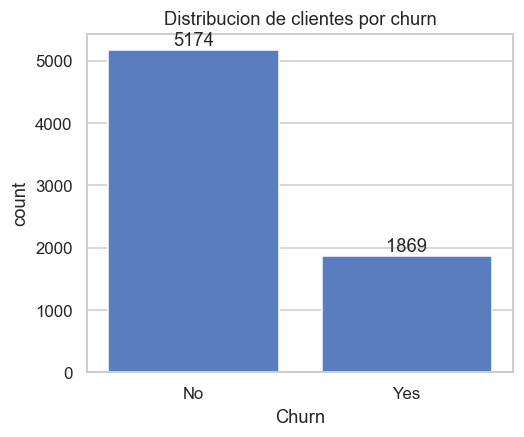

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Churn", ax=ax, order=["No", "Yes"])
for container in ax.containers:
    ax.bar_label(container)
ax.set_title("Distribucion de clientes por churn")
savefig(fig, "01_churn_distribution.png")
plt.show()

### 4.2 Churn por tipo de contrato

Hipotesis: los contratos mes a mes no penalizan la cancelacion, por lo que deberian concentrar el churn.

Figura guardada: C:\Users\Admin\Documents\Análisis y Predicción de Fuga de Clientes\customer-churn-prediction\reports\figures\02_churn_by_contract.png


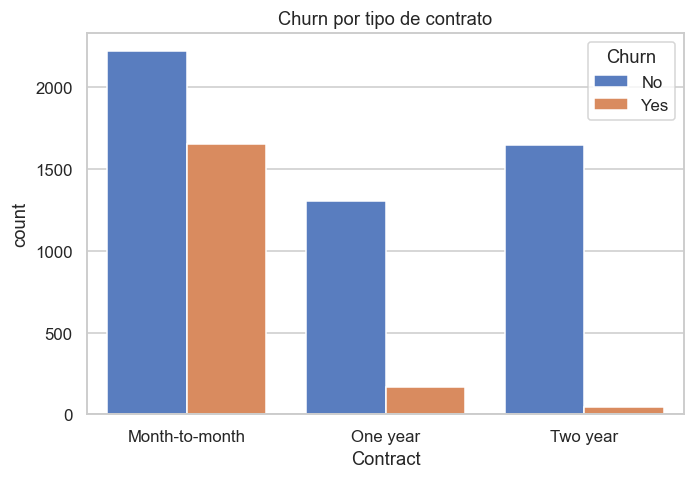

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = ["Month-to-month", "One year", "Two year"]
sns.countplot(data=df, x="Contract", hue="Churn", ax=ax, order=order)
ax.set_title("Churn por tipo de contrato")
savefig(fig, "02_churn_by_contract.png")
plt.show()

### 4.3 Distribucion de antiguedad (tenure) segun churn

Figura guardada: C:\Users\Admin\Documents\Análisis y Predicción de Fuga de Clientes\customer-churn-prediction\reports\figures\03_tenure_distribution.png


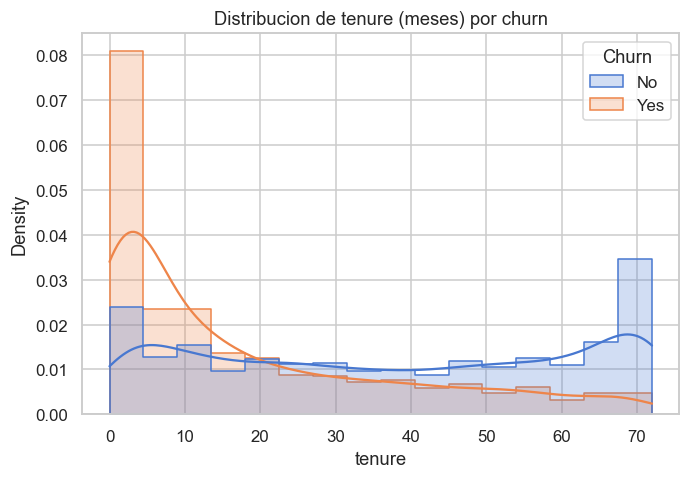

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(data=df, x="tenure", hue="Churn", kde=True, element="step", stat="density", common_norm=False, ax=ax)
ax.set_title("Distribucion de tenure (meses) por churn")
savefig(fig, "03_tenure_distribution.png")
plt.show()

### 4.4 Cargos mensuales segun churn

Figura guardada: C:\Users\Admin\Documents\Análisis y Predicción de Fuga de Clientes\customer-churn-prediction\reports\figures\04_monthlycharges_by_churn.png


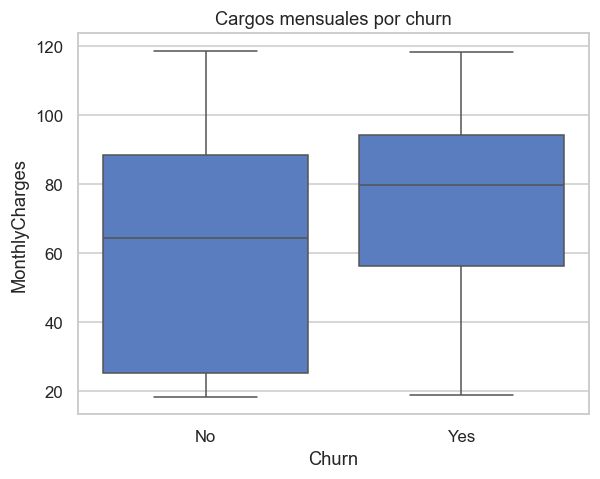

In [10]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", order=["No", "Yes"], ax=ax)
ax.set_title("Cargos mensuales por churn")
savefig(fig, "04_monthlycharges_by_churn.png")
plt.show()

### 4.5 Churn por tipo de servicio de internet

Figura guardada: C:\Users\Admin\Documents\Análisis y Predicción de Fuga de Clientes\customer-churn-prediction\reports\figures\05_churn_by_internet_service.png


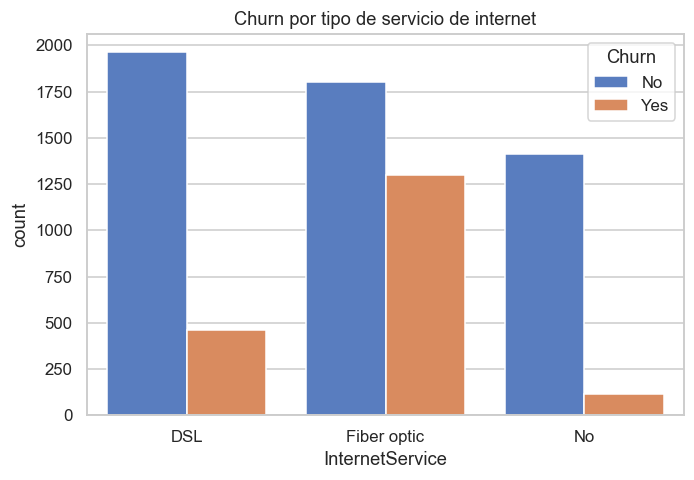

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.countplot(data=df, x="InternetService", hue="Churn", ax=ax)
ax.set_title("Churn por tipo de servicio de internet")
savefig(fig, "05_churn_by_internet_service.png")
plt.show()

### 4.6 Churn por metodo de pago

Figura guardada: C:\Users\Admin\Documents\Análisis y Predicción de Fuga de Clientes\customer-churn-prediction\reports\figures\06_churn_by_payment_method.png


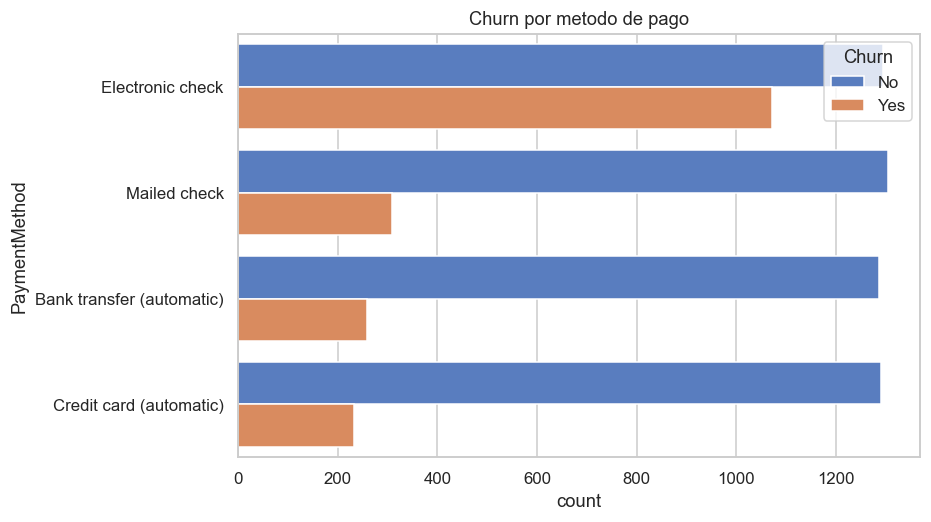

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, y="PaymentMethod", hue="Churn", ax=ax)
ax.set_title("Churn por metodo de pago")
savefig(fig, "06_churn_by_payment_method.png")
plt.show()

### 4.7 Correlacion entre variables numericas

Figura guardada: C:\Users\Admin\Documents\Análisis y Predicción de Fuga de Clientes\customer-churn-prediction\reports\figures\07_correlation_heatmap.png


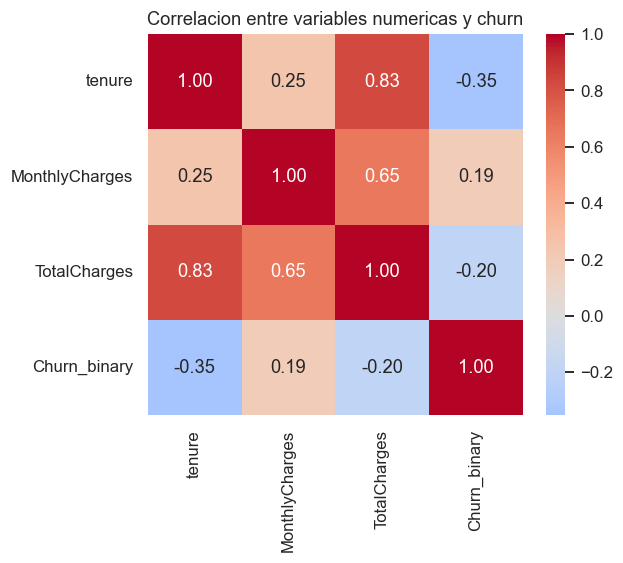

In [13]:
numeric_df = df[["tenure", "MonthlyCharges", "TotalCharges"]].copy()
numeric_df["Churn_binary"] = (df["Churn"] == "Yes").astype(int)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlacion entre variables numericas y churn")
savefig(fig, "07_correlation_heatmap.png")
plt.show()

### 4.8 Tenure vs. cargos mensuales, coloreado por churn

Figura guardada: C:\Users\Admin\Documents\Análisis y Predicción de Fuga de Clientes\customer-churn-prediction\reports\figures\08_tenure_vs_monthlycharges.png


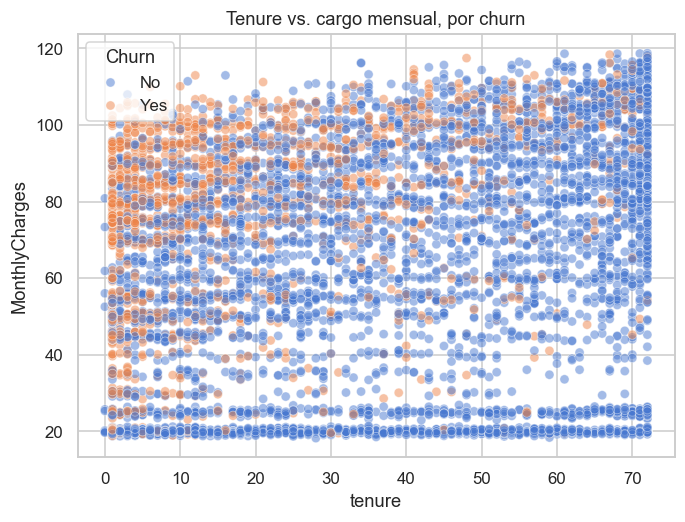

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="Churn", alpha=0.5, ax=ax)
ax.set_title("Tenure vs. cargo mensual, por churn")
savefig(fig, "08_tenure_vs_monthlycharges.png")
plt.show()

### 4.9 Churn por perfil familiar (Partner / Dependents / SeniorCitizen)

Visualizacion adicional: compara tres banderas demograficas binarias en un solo panel.

Figura guardada: C:\Users\Admin\Documents\Análisis y Predicción de Fuga de Clientes\customer-churn-prediction\reports\figures\09_churn_by_family_profile.png


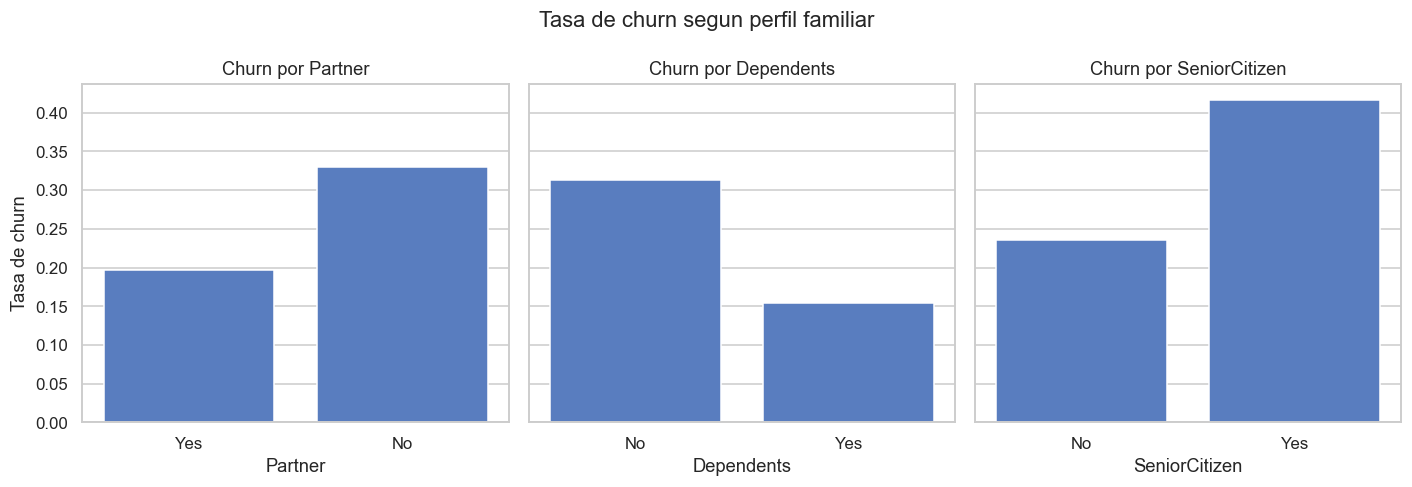

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)
for ax, col in zip(axes, ["Partner", "Dependents", "SeniorCitizen"]):
    sns.barplot(
        data=df.assign(Churn_binary=(df["Churn"] == "Yes").astype(int)),
        x=col, y="Churn_binary", ax=ax, errorbar=None,
    )
    ax.set_ylabel("Tasa de churn")
    ax.set_title(f"Churn por {col}")
fig.suptitle("Tasa de churn segun perfil familiar")
fig.tight_layout()
savefig(fig, "09_churn_by_family_profile.png")
plt.show()

### 4.10 Tasa de churn por servicios contratados (OnlineSecurity, TechSupport)

La falta de servicios de soporte/seguridad suele asociarse a mayor churn (menos "anclaje" al proveedor).

Figura guardada: C:\Users\Admin\Documents\Análisis y Predicción de Fuga de Clientes\customer-churn-prediction\reports\figures\10_churn_by_support_services.png


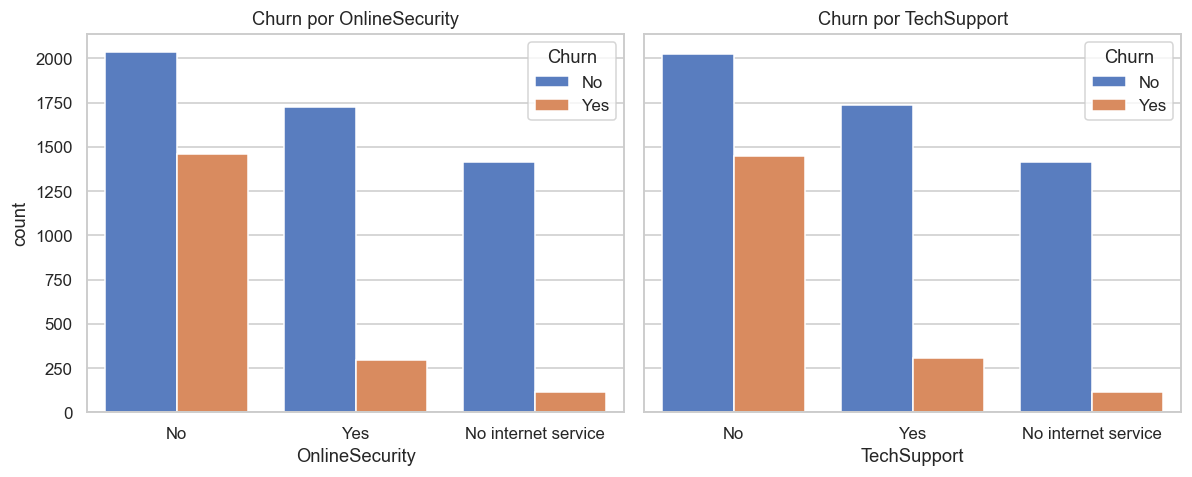

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, col in zip(axes, ["OnlineSecurity", "TechSupport"]):
    sns.countplot(data=df, x=col, hue="Churn", ax=ax)
    ax.set_title(f"Churn por {col}")
fig.tight_layout()
savefig(fig, "10_churn_by_support_services.png")
plt.show()

## 5. Conclusiones de la EDA

- El churn global es de aproximadamente **26.5%**, un desbalance moderado que condiciona las metricas de modelado (ver `src/train_models.py`).
- El **tipo de contrato** es el factor mas asociado al churn: los clientes mes a mes cancelan con mucha mayor frecuencia que los de contrato anual/bianual.
- La **antiguedad (tenure)** baja se asocia fuertemente a churn: los clientes nuevos son mas propensos a cancelar.
- El pago por **cheque electronico** muestra mayor churn que los metodos automaticos.
- Clientes con **fibra optica** y sin servicios adicionales (OnlineSecurity, TechSupport) muestran mayor churn, probablemente por precio mas alto y menor "anclaje" al servicio.

Estos hallazgos son consistentes con lo que despues confirma la importancia de variables del mejor modelo entrenado (`reports/figures/feature_importance.png`).